# **INTELIGENCIA ARTIFICIAL (1INF24)**<br>
## **2025-1**


---

# **EXAMEN 1 - Parte 2**

**Indicaciones generales:**
- Duración: **100 minutos (1:50 min)**.
- Para responder las preguntas de esta parte <font color='red'>SOLO SE PERMITE LOS NOTEBOOKS DADOS EN CLASE</font>
- Es <font color='red'>OBLIGATORIO DESHABILITAR ASISTENCIA DE IA</font> (Tools->Settings->AI Assistant). De no hacerlo puede ser anulada su evaluacion. Se verificara ello en los  logs y remotamente con AB Tutor.  
- Cualquier indicio de plagio resultará en la anulación de la prueba.
- Subir el cuadernillo con el nombre **Examen1-Parte2_código.ipynb**, donde código es su código PUCP de 8 dígitos.  
- Se tomará en cuenta en la calificación la precision de la respuesta y el uso adecuado del lenguaje.
---

# Preparacion de datos y Construccion de Modelos de Regresion  (10 puntos)

Se disponde de un conjunto de datos (**forestfires.xlsx**) de incendios forestales ocurridos en el Parque Natural Montesinho (Portugal), los cuales utilizaremos para construir predictores del área quemada (variable **area**) de incendios de acuerdo a los atributos del mismo. El mapa ha sido dividido en un grillado de 9x9. Los atributos que se tiene son los siguientes:

### ATRIBUTOS:
* X = Coordenada espacial X de la grilla donde ocurrio el incendio (entre 1 a 9),
* Y = Coordenada espacial Y de la grilla donde ocurrio el incendio (entre 1 a 9),
* month = mes de ocurrencia del incendio (de 'jan' a 'dec'),
* day = dia de la semana de ocurrencia del incendio,
* FFMC = índice de humedad del combustible fino (FFMC). Representa el estado de humedad de la hojarasca a profundidades de 1 a 5 cm con un intervalo de 16 horas. Su rango es de 1 a 101,
* DMC = índice de humedad de la hojarasca. Representa el estado de humedad del material orgánica bajo la hojarasca a profundidad de 5 a 10 cm con un intervalo de 360 horas. Su rango es de 0 a 300,  
* DC = Representa el estado de humedad del suelo profundo a profundidades de 10 a 20 cm con un intervalo de 52 dias. Su rango es de 0 a 1200,
* ISI = índice de propagación inicial (ISI) es la combinación de la velocidad del viento y el índice de humedad del combustible (FMC). No tiene unidades y es abierto. Se utiliza para estimar el potencial de propagación,
* temp = temperatura (grados centigrados),
* RH  = humedad relativa. Su rango es de 0 a 100,
* wind = velocidad del viento (km/h) ,
* rain = cantidad de lluvia (mm/m2)
* area (Variable Target) =  área quemada en hectareas (de 0 a 1090.84 ha)

Con este dataset se requiere que usted haga el preprocesamiento y evaluacion de algoritmos de regresion para predecir el área quemada (area) con base a las otras variables. **Es importante que los modelos que usted evalue puedan servir para predecir el área quemada de incendios nuevos que puedan ocurrir dentro del Parque Natural Montesinho**

Se le pide que elabore y ejecute codigo en Python para realizar las siguientes tareas:

**1) Limpiar el dataset con el fin de obtener un conjunto de datos limpio y con informacion relevante. Los pasos que puede elegir aplicar aqui pueden ser: dropeos de columnas, dropeos de filas, remoción de outliers, filas duplicadas y datos inconsistentes, imputacion de nulos. Cada paso elegido debe ser justificado. Se valora el uso de plots adecuados para esta etapa** (2 puntos)

In [47]:
# RESPUESTA


# Librerías:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


# Abrir los datos


df = pd.read_excel('forestfires.xlsx')

## Preprocesar lo necesario:


# Primero, evaluaremos que es lo que tienen las variables.

# evaluaremos la informacion:

df.info()

#descripción, que incluye todo.

df.describe(include='all')

#agregar los valores nulos:

print("Los valores nulos son: \n",df.isnull().sum())

# Valores nulos encontrados: RH:2 y mont:3

numDuplicados = df.duplicated().sum()
print("Los valroes duplicados son: ",numDuplicados)

if(numDuplicados > 0):
  df = df.drop_duplicates()

# Revisión de categorías
print("Valores únicos en 'month':", df['month'].unique())
print("Valores únicos en 'day':", df['day'].unique())

# Llenar valores vacíos:

# Primero, los vacíos de los números, luego los vacíos

#Sacamos el numero de columnas que son datos netamente numericos.

num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
  if df[col].isnull().sum() > 0:
    df[col].fillna(df[col].median(),inplace=True)


# Ahora, las que son solo columnas.

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
  if df[col].isnull().sum() > 0:
    df[col].fillna(df[col].mode()[0],inplace=True)



print("Los valores nullos al final son: \n",df.isnull().sum())





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   514 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      515 non-null    float64
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(9), int64(2), object(2)
memory usage: 52.6+ KB
Los valores nulos son: 
 X        0
Y        0
month    3
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       2
wind     0
rain     0
area     0
dtype: int64
Los valroes duplicados son:  4
Valores únicos en 'month': ['mar' 'oct' 'aug' 'sep' 'apr' 'jun' '

**2) Codifique cada variable categorica con la codificacion adecuada (Label Encoding o OneHot Encoding). Justifique sus elecciones** (1 punto)


In [56]:
# RESPUESTA

from sklearn.preprocessing import LabelEncoder
import pandas as pd

cat_columns = df.select_dtypes(include='object').columns
print("Variables categoricas: ",list(cat_columns))

# Codificación
# Como no poseen un orden natural o algo, se le aplica one hot encoding con dummys.

df = pd.get_dummies(df,columns=['month','day'],drop_first=True)

print("Dimensión del dataset tras codificación:", df.shape)
df.head()



Variables categoricas:  ['month', 'day']
Dimensión del dataset tras codificación: (513, 28)


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_may,month_nov,month_oct,month_sep,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,7,5,86.2,26.2,94.3,5.1,8.2,51.0,6.7,0.0,...,False,False,False,False,False,False,False,False,False,False
1,7,4,90.6,35.4,669.1,6.7,18.0,33.0,0.9,0.0,...,False,False,True,False,False,False,False,False,True,False
2,7,4,90.6,43.7,686.9,6.7,14.6,33.0,1.3,0.0,...,False,False,True,False,False,True,False,False,False,False
3,8,6,91.7,33.3,77.5,9.0,8.3,97.0,4.0,0.2,...,False,False,False,False,False,False,False,False,False,False
4,8,6,89.3,51.3,102.2,9.6,11.4,99.0,1.8,0.0,...,False,False,False,False,False,False,True,False,False,False


**3) Genere e interprete un plot de correlaciones entre las variables. Si observa pares de variables con correlaciones elevadas (mayores a 0.90) escoja solo una de ellas** (1 punto)


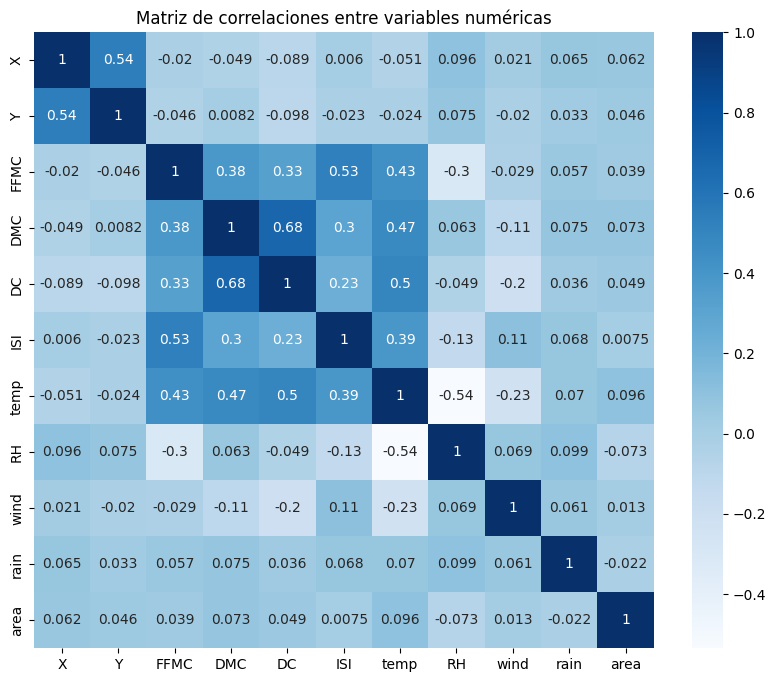

In [66]:
# RESPUESTA

import seaborn as sns
import matplotlib.pyplot as plt

#Sin incluir las variabless dummys.

num_cols = ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain','area']
corr_matrix = df[num_cols].corr()

# Creacion del plot:

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='Blues',annot=True)
plt.title('Matriz de correlaciones entre variables numéricas')
plt.show()








**4) Dividir el dataset procesado en dos conjuntos: train y test. Usar 80% de los datos para train y 20% para test** (0 puntos)


In [76]:
# RESPUESTA

from sklearn.model_selection import train_test_split

X = df.drop(columns=['area'])
Y = df['area']

X_train, X_test, y_train, y_test =  train_test_split(X,Y,test_size = 0.20, random_state=42)


# Verificar tamaños resultantes
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")


Conjunto de entrenamiento: 410 muestras
Conjunto de prueba: 103 muestras


**5) Con el conjunto de train evalue en crosvalidación los siguientes algoritmos de regresión: Linear Regresion, Ridge Regresion, Lasso Regresion, ElasticNet Regresion, KNN (K=5), KNN (K=10), Decision Tree Regresion (max_depth=20), Decision Tree Regresion (max_depth=None). Use 10 folds para la crosvalidación y como métrica de scoring use 'neg_mean_squared_error'. Muestre boxplots de los resultados de la crossvalidacion de todos los algoritmos evaluados y comente los resultados.** (2 puntos)  


LinearReg: media = -5257.5098, desviación = 9032.8693
Ridge: media = -5235.4528, desviación = 9053.6596
Lasso: media = -5073.2680, desviación = 9045.7623
ElasticNet: media = -5041.5427, desviación = 9054.4271
KNN5: media = -5878.6217, desviación = 9245.4736
KNN10: media = -5632.8213, desviación = 9352.7038
Tree20: media = -7228.1068, desviación = 9310.3897
TreeNone: media = -7176.8472, desviación = 9531.4156


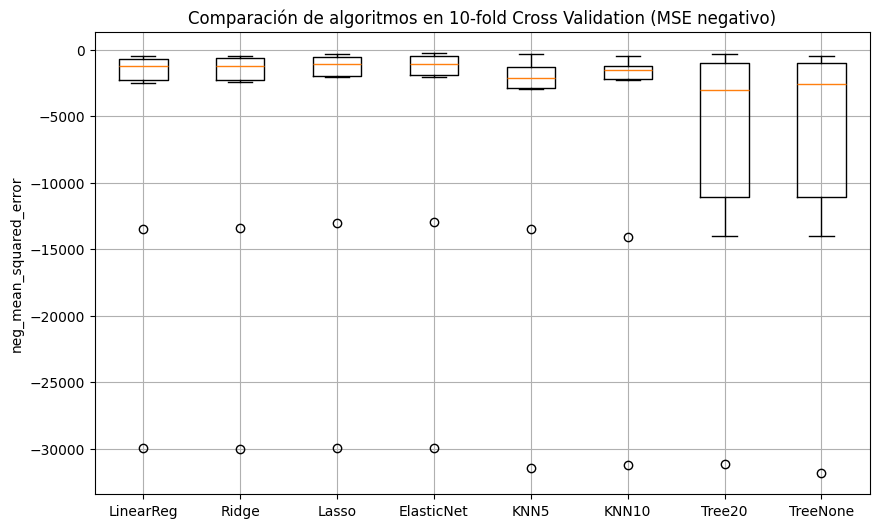

In [83]:
# RESPUESTA


#Importamos los modelos :

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

#Definimos los modelos a usar:

models = []

models.append(('LinearReg', LinearRegression()))
models.append(('Ridge', Ridge()))
models.append(('Lasso', Lasso()))
models.append(('ElasticNet', ElasticNet()))
models.append(('KNN5', KNeighborsRegressor(n_neighbors=5)))
models.append(('KNN10', KNeighborsRegressor(n_neighbors=10)))
models.append(('Tree20', DecisionTreeRegressor(max_depth=20)))
models.append(('TreeNone', DecisionTreeRegressor(max_depth=None)))

# Configurar validación cruzada (10 folds)
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = 'neg_mean_squared_error'

# Ahora, evaluamos cada uno de los modelos:

results = []
names = []

for name, model in models:
  cv_results = cross_val_score(model,X_train,y_train,cv=kfold,scoring=scoring)
  results.append(cv_results)
  names.append(name)
  print(f"{name}: media = {cv_results.mean():.4f}, desviación = {cv_results.std():.4f}")

# === Boxplot comparativo de los modelos ===
plt.figure(figsize=(10,6))
plt.boxplot(results, labels=names)
plt.title('Comparación de algoritmos en 10-fold Cross Validation (MSE negativo)')
plt.ylabel('neg_mean_squared_error')
plt.grid(True)
plt.show()



**6) Con base a los resultados del paso 5 escoja el algoritmo que mejores modelos induce y entrene con él un modelo final usando todos los datos de entrenamiento y evalúelo en la data separada para prueba (paso 4). Muestre las metricas MAE y R2 en el conjunto de test. Muestre un scatter plot de los valores reales vs los predichos en el conjunto de test y comente los resultados.** (1 puntos)  


Mean Absolute Error (MAE): 15.4047
Coeficiente de determinación (R²): -0.2557


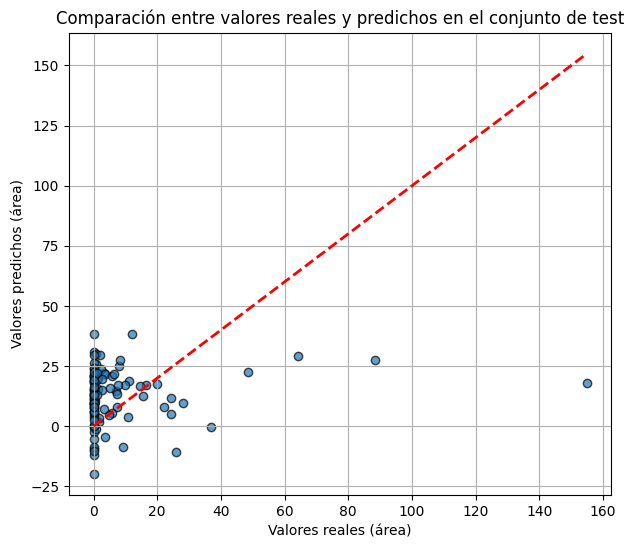

In [90]:
# RESPUESTA

from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

model_final = ElasticNet()
model_final.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = model_final.predict(X_test) # X test : incendios que el modelo no ha visto antes.

# Calcular métricas solicitadas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coeficiente de determinación (R²): {r2:.4f}")

# === Scatter plot: valores reales vs. predichos ===
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, edgecolor='k', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel('Valores reales (área)')
plt.ylabel('Valores predichos (área)')
plt.title('Comparación entre valores reales y predichos en el conjunto de test')
plt.grid(True)
plt.show()


**7) Muestre plot de distribucion de la variable target y comente sobre si existe algun sesgo y cómo se relaciona ello con los resultados obtenidos en el paso 6. Comente de forma justificada qué mejoras propone para mejorar los resultados**   (2 puntos)  


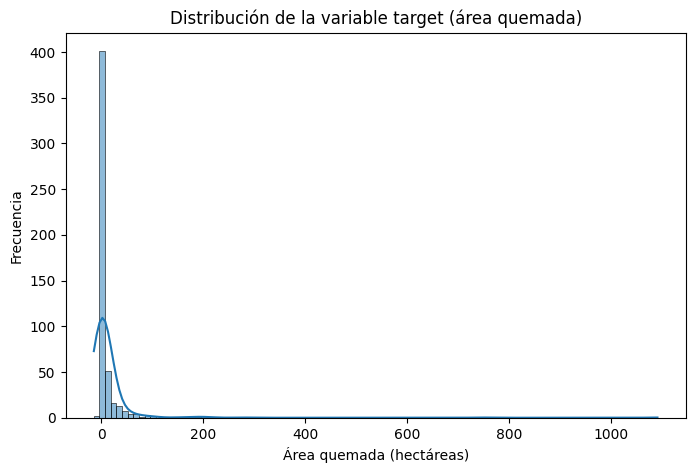

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot de distribución de la variable 'area'
plt.figure(figsize=(8,5))
sns.histplot(df['area'], bins=100,kde=True)
plt.title('Distribución de la variable target (área quemada)')
plt.xlabel('Área quemada (hectáreas)')
plt.ylabel('Frecuencia')
plt.show()

RESPUESTA: Esto significa que la mayoría de los incendios registran áreas pequeñas (cercanas a 0 hectáreas), mientras que unos pocos incendios extremos queman áreas muy grandes (valores altos de hasta cientos de hectáreas).


**8) Explique brevemente ¿por qué se hace crosvalidación en el conjunto de train para evaluar los algoritmos de machine learning? ¿Por que no simplemente se entrena modelos con todo train y se los evalua en el conjunto de test?**  (1 puntos)


RESPUESTA: Se hace cross-validación en train para estimar de forma robusta el rendimiento de los modelos sin contaminar el conjunto test, que debe reservarse para la evaluación final e imparcial.
